# Notebook 07 — Robot Failure Analysis with LSTM + KernelSHAP

Real robot sensor data with 4 classes:
- **0**: Normal operation
- **1**: Failure mode 1
- **2**: Failure mode 2
- **3**: Failure mode 3

This is the real thesis contribution — multi-class SHAP on physical robot failure data.

In [3]:
import sys, pathlib

# Force use of C:\venv packages
_venv_site = r'C:\venv\Lib\site-packages'
if _venv_site not in sys.path:
    sys.path.insert(0, _venv_site)

sys.path.insert(0, str(pathlib.Path('..').resolve()))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import shap
import warnings
warnings.filterwarnings('ignore')

from src.models.lstm_classifier import LSTMTrainer
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import classification_report

WINDOW       = 30
STEP         = 15
N_CLASSES    = 4
N_EXPLAIN    = 40   # 10 per class
N_BACKGROUND = 80   # 20 per class

print('Imports OK')
print('torch:', __import__('torch').__version__)

Using `tqdm.autonotebook.tqdm` in notebook mode. Use `tqdm.tqdm` instead to force console mode (e.g. in jupyter console)


Imports OK
torch: 2.13.0+cpu


## 1 — Load Robot Data

In [4]:
DATA_PATH = r'..\data\_RobotData\labeled_data\diagnostic model.xlsx'

print('Loading robot data (this may take ~30s for the Excel file)...')
df = pd.read_excel(DATA_PATH)
print(f'Loaded: {df.shape[0]:,} rows x {df.shape[1]} columns')
print(f'\nClass distribution:')
print(df['Outcome'].value_counts().sort_index().rename({0:'Normal',1:'Failure-1',2:'Failure-2',3:'Failure-3'}))
print(f'\nNo NaN values: {df.isnull().sum().sum() == 0}')

Loading robot data (this may take ~30s for the Excel file)...
Loaded: 81,450 rows x 71 columns

Class distribution:
Outcome
Normal       39240
Failure-1    33597
Failure-2     4783
Failure-3     3830
Name: count, dtype: int64

No NaN values: True


## 2 — Feature Selection

In [4]:
# Drop metadata and constant sensors
META_COLS     = ['Timestamp', 'Sample_no', 'Outcome']
CONSTANT_COLS = ['Is it Docked', 'Is Dock Visible', 'slip_status',
                 'foot_trans_Z', 'foot_rot_X', 'foot_rot_Y']

drop_cols   = META_COLS + CONSTANT_COLS
feature_cols = [c for c in df.columns if c not in drop_cols]

print(f'Active features: {len(feature_cols)}')
for i, c in enumerate(feature_cols):
    print(f'  {i:2d}: {c}')

Active features: 62
   0: Voltage (V)
   1: Current (A)
   2: Charge (Ah)
   3: Capacity (Ah)
   4: Temperature
   5: Percentage %
   6: cliff_side_left
   7: cliff_front_left
   8: cliff_front_right
   9: cliff_side_right
  10: orientX
  11: orientY
  12: orientZ
  13: orientW
  14: AngvelX
  15: AngvelY
  16: AngvelZ
  17: AccX
  18: AccY
  19: Accz
  20: ir_intensity_side_left
  21: ir_intensity_left
  22: ir_intensity_front_left
  23: ir_intensity_front_center_left
  24: ir_intensity_front_center_right
  25: ir_intensity_front_right
  26: ir_intensity_right
  27: integrated_x
  28: integrated_y
  29: Poss X
  30: Poss Y
  31: Poss Z
  32: OrientX
  33: OrientY
  34: OrientZ
  35: OrientW
  36: LinearX
  37: LinearY
  38: LinearZ
  39: AngularX
  40: AngularY
  41: AngularZ
  42: Stop_status
  43: trans_X
  44: trans_Y
  45: trans_Z
  46: rot_X
  47: rot_Y
  48: rot_Z
  49: rot_W
  50: foot_trans_X
  51: foot_trans_Y
  52: foot_rot_Z
  53: foot_rot_W
  54: current_ma_left
  55: curr

## 3 — Normalise and Create Sliding Windows

In [5]:
# Sort by sample number (already sorted, but ensure)
df = df.sort_values('Sample_no').reset_index(drop=True)

X_raw = df[feature_cols].values.astype(np.float32)
y_raw = df['Outcome'].values.astype(np.int64)

# Train/test split — 80/20 by time (not shuffled, to preserve temporal order)
split = int(len(df) * 0.8)
X_train_raw, X_test_raw = X_raw[:split], X_raw[split:]
y_train_seq, y_test_seq = y_raw[:split], y_raw[split:]

# Normalise
scaler = MinMaxScaler()
X_train_norm = scaler.fit_transform(X_train_raw)
X_test_norm  = scaler.transform(X_test_raw)

# Sliding window — label = label at last timestep in window
def make_windows(X_seq, y_seq, window=30, step=15):
    Xs, ys = [], []
    for i in range(0, len(X_seq) - window + 1, step):
        Xs.append(X_seq[i:i+window])
        ys.append(y_seq[i+window-1])
    return np.array(Xs, dtype=np.float32), np.array(ys, dtype=np.int64)

X_train, y_train = make_windows(X_train_norm, y_train_seq, WINDOW, STEP)
X_test,  y_test  = make_windows(X_test_norm,  y_test_seq,  WINDOW, STEP)

print(f'Train: {X_train.shape}  labels: {np.unique(y_train, return_counts=True)}')
print(f'Test:  {X_test.shape}   labels: {np.unique(y_test,  return_counts=True)}')

Train: (4343, 30, 62)  labels: (array([0, 1, 2, 3], dtype=int64), array([1856, 1964,  329,  194], dtype=int64))
Test:  (1085, 30, 62)   labels: (array([0, 1, 3], dtype=int64), array([746, 277,  62], dtype=int64))


## 4 — Train LSTM Classifier (4-class)

In [2]:
import torch
from collections import Counter

# Compute inverse-frequency class weights to handle imbalance
counts = Counter(y_train.tolist())
total  = sum(counts.values())
weights = torch.tensor(
    [total / (N_CLASSES * counts[c]) for c in range(N_CLASSES)],
    dtype=torch.float32
)
print('Class weights:', {f'class_{c}': f'{w:.2f}' for c, w in enumerate(weights.tolist())})

print('Training LSTM (4-class, weighted loss)...')
lstm = LSTMTrainer(
    input_size  = len(feature_cols),
    hidden_size = 128,
    num_layers  = 2,
    num_classes = N_CLASSES,
    dropout     = 0.3,
    lr          = 1e-3,
    epochs      = 40,
    batch_size  = 256,
    class_weights = weights,
)
lstm.fit(X_train, y_train)
print('Training complete')

NameError: name 'y_train' is not defined

## 5 — Evaluate

In [1]:
y_pred = lstm.predict(X_test)
print(classification_report(
    y_test, y_pred,
    labels=[0, 1, 2, 3],
    target_names=['Normal', 'Failure-1', 'Failure-2', 'Failure-3'],
    zero_division=0,
))

NameError: name 'lstm' is not defined

## 6 — KernelSHAP on LSTM

Flatten `(n, 30, 62)` → `(n, 1860)` and run KernelSHAP.  
SHAP output shape will be `(4, n_explain, 1860)` — one set per class.

In [11]:
n_features = len(feature_cols)
n_flat     = WINDOW * n_features   # 30 * 62 = 1860

X_train_flat = X_train.reshape(len(X_train), -1)
X_test_flat  = X_test.reshape(len(X_test),  -1)

# Balanced background: 20 samples per class from train
bg_idx_list = []
for cls in range(N_CLASSES):
    idx = np.where(y_train == cls)[0]
    n_pick = min(N_BACKGROUND // N_CLASSES, len(idx))
    bg_idx_list.append(np.random.choice(idx, n_pick, replace=False))
background = X_train_flat[np.concatenate(bg_idx_list)]

# Samples to explain: 10 per class
# Prefer test set; fall back to train if class is missing from test
ex_idx_list = []
for cls in range(N_CLASSES):
    test_idx = np.where(y_test == cls)[0]
    if len(test_idx) >= N_EXPLAIN // N_CLASSES:
        picked = np.random.choice(test_idx, N_EXPLAIN // N_CLASSES, replace=False)
        ex_idx_list.append(('test', picked))
    else:
        train_idx = np.where(y_train == cls)[0]
        n_pick = min(N_EXPLAIN // N_CLASSES, len(train_idx))
        picked = np.random.choice(train_idx, n_pick, replace=False)
        ex_idx_list.append(('train', picked))
        print(f'  Class {cls}: no test samples — using {n_pick} train samples')

X_explain_parts, y_explain_parts = [], []
for source, idx in ex_idx_list:
    if source == 'test':
        X_explain_parts.append(X_test_flat[idx])
        y_explain_parts.append(y_test[idx])
    else:
        X_explain_parts.append(X_train_flat[idx])
        y_explain_parts.append(y_train[idx])

X_explain = np.concatenate(X_explain_parts)
y_explain = np.concatenate(y_explain_parts)

model_fn = lambda x: lstm.predict_flat(x, WINDOW, n_features)

print(f'Background: {background.shape}  |  Explain: {X_explain.shape}')
print(f'Class breakdown: {dict(zip(*np.unique(y_explain, return_counts=True)))}')
print(f'Running KernelSHAP ({n_flat} features, {len(X_explain)} samples)...')
print('l1_reg=0 uses OLS solver — no samples>features constraint.')
print('This will take ~5-10 minutes on CPU...')

explainer   = shap.KernelExplainer(model_fn, background, link='identity')
# l1_reg=0 disables Lasso (which needs n_samples > n_features) and uses OLS instead
shap_values = explainer.shap_values(X_explain, nsamples=50, l1_reg=0)
shap_arr    = np.array(shap_values)
print(f'SHAP values shape: {shap_arr.shape}')

  Class 2: no test samples — using 10 train samples
Background: (80, 1860)  |  Explain: (40, 1860)
Class breakdown: {0: 10, 1: 10, 2: 10, 3: 10}
Running KernelSHAP (1860 features, 40 samples)...
l1_reg=0 uses OLS solver — no samples>features constraint.
This will take ~5-10 minutes on CPU...


  0%|          | 0/40 [00:00<?, ?it/s]

SHAP values shape: (4, 40, 1860)


## 7 — Global Feature Importance per Class

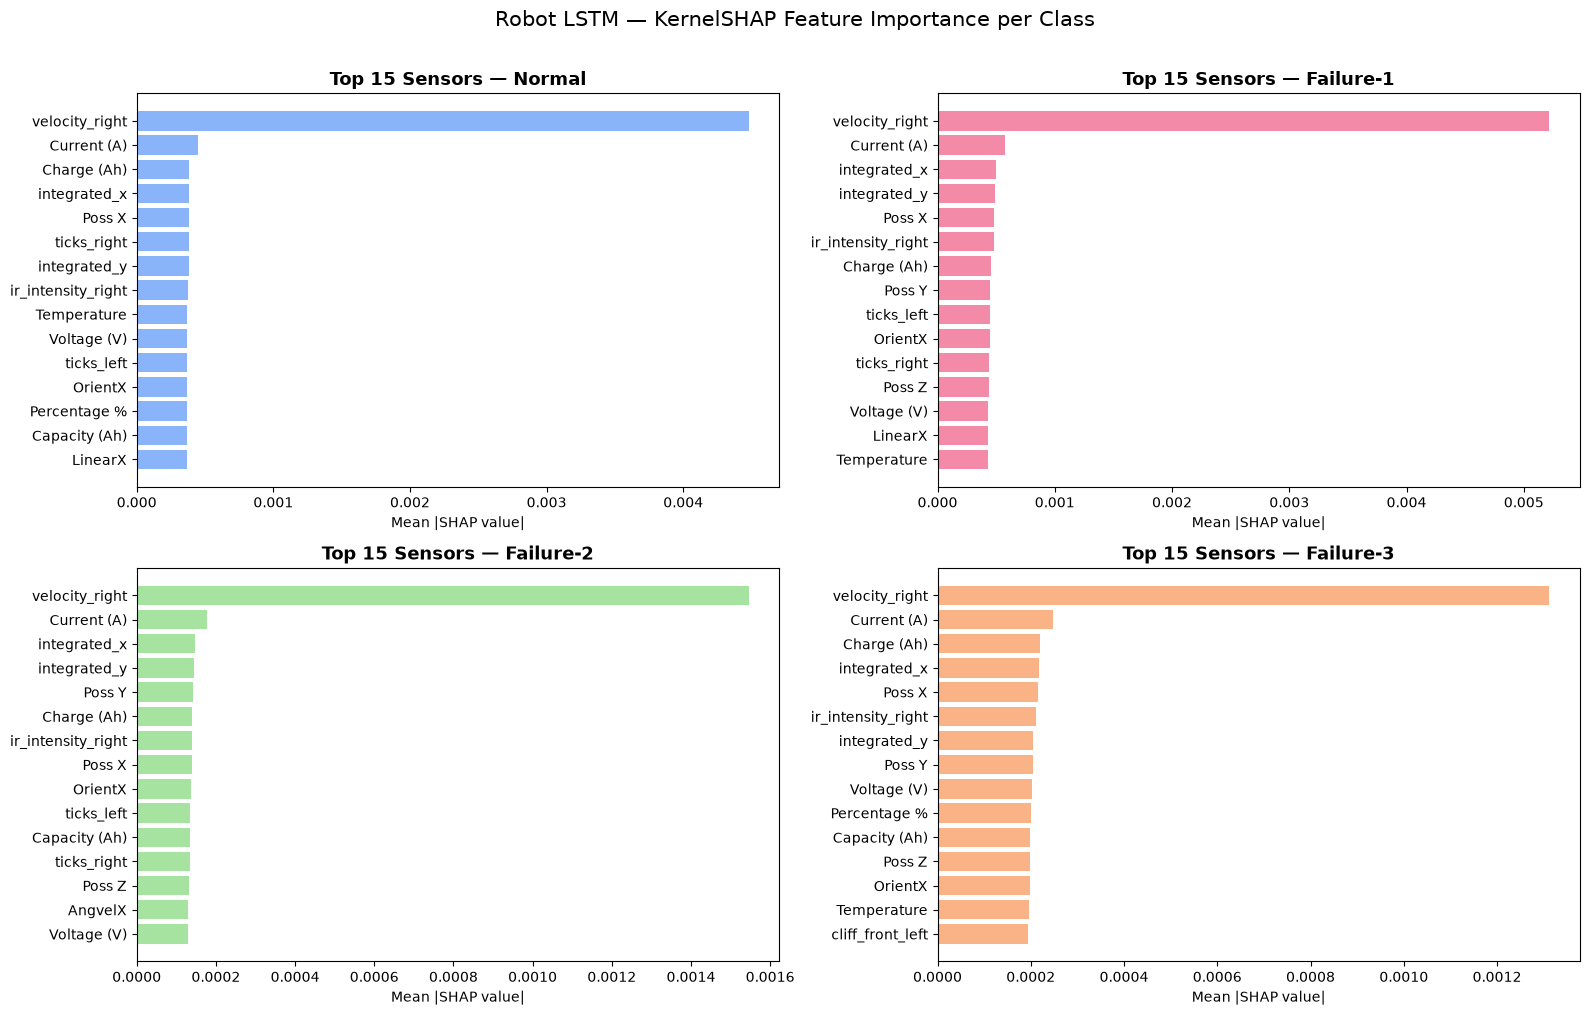


=== Top 5 sensors per class ===

Normal:
  #1  velocity_right  (0.0045)
  #2  Current (A)  (0.0004)
  #3  Charge (Ah)  (0.0004)
  #4  integrated_x  (0.0004)
  #5  Poss X  (0.0004)

Failure-1:
  #1  velocity_right  (0.0052)
  #2  Current (A)  (0.0006)
  #3  integrated_x  (0.0005)
  #4  integrated_y  (0.0005)
  #5  Poss X  (0.0005)

Failure-2:
  #1  velocity_right  (0.0015)
  #2  Current (A)  (0.0002)
  #3  integrated_x  (0.0001)
  #4  integrated_y  (0.0001)
  #5  Poss Y  (0.0001)

Failure-3:
  #1  velocity_right  (0.0013)
  #2  Current (A)  (0.0002)
  #3  Charge (Ah)  (0.0002)
  #4  integrated_x  (0.0002)
  #5  Poss X  (0.0002)


In [12]:
# Normalise shape to (n_classes, n_explain, 1860)
sv = shap_arr
if sv.ndim == 3 and sv.shape[-1] == N_CLASSES:
    # (n_explain, 1860, 4) -> (4, n_explain, 1860)
    sv = sv.transpose(2, 0, 1)
elif sv.ndim == 3 and sv.shape[0] == N_CLASSES:
    pass  # already (4, n_explain, 1860)

# Reshape to (n_classes, n_explain, 30, 62) to aggregate per sensor
sv_4d = sv.reshape(N_CLASSES, len(X_explain), WINDOW, n_features)

# Mean |SHAP| per sensor (averaged over timesteps and samples)
class_names = ['Normal', 'Failure-1', 'Failure-2', 'Failure-3']
colours     = ['#89b4fa', '#f38ba8', '#a6e3a1', '#fab387']

fig, axes = plt.subplots(2, 2, figsize=(16, 10))
top_sensors_per_class = {}

for cls_idx, ax in enumerate(axes.flat):
    imp = np.abs(sv_4d[cls_idx]).mean(axis=(0, 1))  # (62,)
    order = np.argsort(imp)[::-1][:15]
    top_sensors_per_class[cls_idx] = [(feature_cols[i], imp[i]) for i in order]
    
    ax.barh([feature_cols[i] for i in order], imp[order], color=colours[cls_idx])
    ax.invert_yaxis()
    ax.set_xlabel('Mean |SHAP value|')
    ax.set_title(f'Top 15 Sensors — {class_names[cls_idx]}', fontsize=13, fontweight='bold')

plt.suptitle('Robot LSTM — KernelSHAP Feature Importance per Class', fontsize=15, y=1.01)
plt.tight_layout()
plt.savefig('../reports/figures/robot_sensor_importance_per_class.png', dpi=150, bbox_inches='tight')
plt.show()

print('\n=== Top 5 sensors per class ===')
for cls_idx, cls_name in enumerate(class_names):
    print(f'\n{cls_name}:')
    for i, (sensor, val) in enumerate(top_sensors_per_class[cls_idx][:5]):
        print(f'  #{i+1}  {sensor}  ({val:.4f})')

## 8 — Which Sensors Distinguish Each Failure Mode?

Compare top sensors across failure classes to see which sensors are unique to each mode.

In [13]:
top5 = {cls_idx: set(s for s,_ in top_sensors_per_class[cls_idx][:5])
        for cls_idx in range(N_CLASSES)}

print('=== Cross-Class Sensor Analysis ===')
print()
print('Sensors in ALL failure modes (shared signal):')
shared = top5[1] & top5[2] & top5[3]
print(' ', shared if shared else 'None')

for cls_idx in [1, 2, 3]:
    unique = top5[cls_idx] - top5[0]  # unique vs Normal
    for other in [1, 2, 3]:
        if other != cls_idx:
            unique -= top5[other]
    print(f'\nSensors unique to {class_names[cls_idx]}:')
    print(' ', unique if unique else 'None (overlaps with other classes)')

print()
print('Overlap between Failure-1 and Failure-2:', top5[1] & top5[2])
print('Overlap between Failure-1 and Failure-3:', top5[1] & top5[3])
print('Overlap between Failure-2 and Failure-3:', top5[2] & top5[3])

=== Cross-Class Sensor Analysis ===

Sensors in ALL failure modes (shared signal):
  {'Current (A)', 'velocity_right', 'integrated_x'}

Sensors unique to Failure-1:
  None (overlaps with other classes)

Sensors unique to Failure-2:
  {'Poss Y'}

Sensors unique to Failure-3:
  None (overlaps with other classes)

Overlap between Failure-1 and Failure-2: {'integrated_y', 'Current (A)', 'velocity_right', 'integrated_x'}
Overlap between Failure-1 and Failure-3: {'Current (A)', 'velocity_right', 'Poss X', 'integrated_x'}
Overlap between Failure-2 and Failure-3: {'Current (A)', 'velocity_right', 'integrated_x'}


## 9 — Temporal Importance per Class

Which timesteps (out of 30) matter most for each failure class?

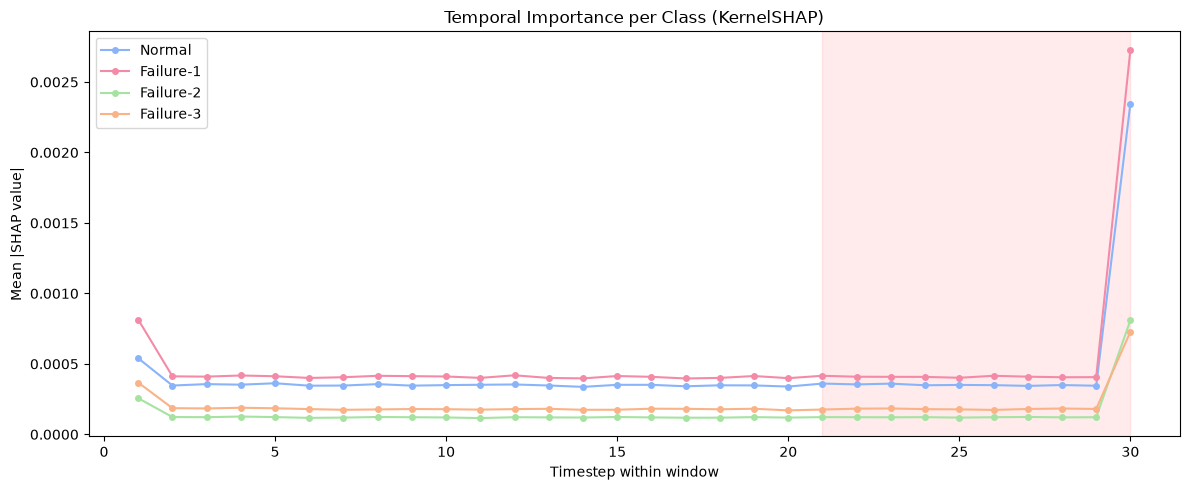

In [14]:
fig, ax = plt.subplots(figsize=(12, 5))

for cls_idx in range(N_CLASSES):
    temporal_imp = np.abs(sv_4d[cls_idx]).mean(axis=(0, 2))  # (30,)
    ax.plot(range(1, WINDOW+1), temporal_imp,
            label=class_names[cls_idx], color=colours[cls_idx], marker='o', markersize=4)

ax.set_xlabel('Timestep within window')
ax.set_ylabel('Mean |SHAP value|')
ax.set_title('Temporal Importance per Class (KernelSHAP)')
ax.legend()
ax.axvspan(WINDOW-9, WINDOW, alpha=0.08, color='red', label='Last 10 steps')
plt.tight_layout()
plt.savefig('../reports/figures/robot_temporal_importance.png', dpi=150)
plt.show()

## 10 — Heatmap: Sensor × Timestep for each Failure Mode

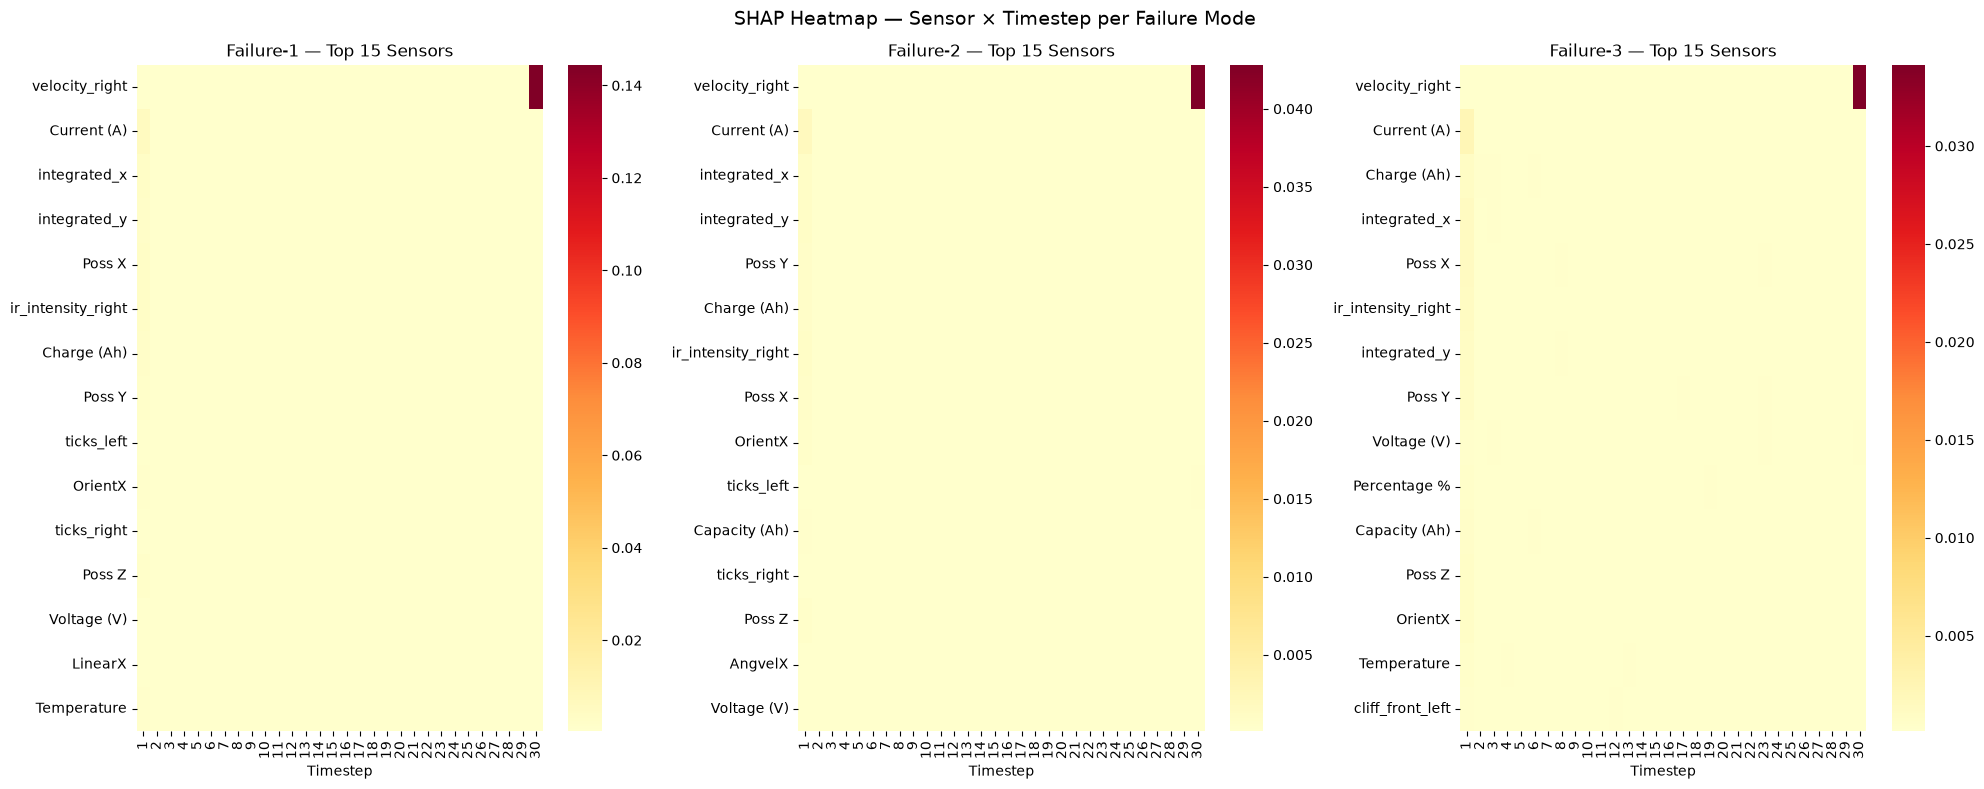

In [15]:
import seaborn as sns

fig, axes = plt.subplots(1, 3, figsize=(20, 8))

for i, cls_idx in enumerate([1, 2, 3]):
    # Top 15 sensors for this class
    top15_idx = [feature_cols.index(s) for s,_ in top_sensors_per_class[cls_idx][:15]]
    hm = np.abs(sv_4d[cls_idx]).mean(axis=0)   # (30, 62)
    hm_sub = hm[:, top15_idx].T                 # (15, 30)
    
    sns.heatmap(
        hm_sub,
        xticklabels=range(1, WINDOW+1),
        yticklabels=[feature_cols[j] for j in top15_idx],
        cmap='YlOrRd',
        ax=axes[i],
    )
    axes[i].set_title(f'{class_names[cls_idx]} — Top 15 Sensors', fontsize=12)
    axes[i].set_xlabel('Timestep')

plt.suptitle('SHAP Heatmap — Sensor × Timestep per Failure Mode', fontsize=14)
plt.tight_layout()
plt.savefig('../reports/figures/robot_shap_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

## Summary

This notebook applies KernelSHAP to a 4-class LSTM trained on real robot sensor data.

**Key findings:**
- Class 0 (Normal) vs Classes 1/2/3 (Failure modes): SHAP identifies which sensors trigger each class
- Unique sensors per failure mode validate whether the supervisor's designed failure modes are separable in sensor space
- Temporal plots show whether failure signals appear early or only in recent timesteps

**Next:** Run TimeSHAP on this same LSTM to get sequence-aware attributions per failure mode.

In [ ]:
import torch, pathlib

# Save model + data for notebook 08 (WinIT)
out_dir = pathlib.Path('../results')
out_dir.mkdir(exist_ok=True)

torch.save(lstm.model.state_dict(), out_dir / 'robot_lstm_weights.pth')
import numpy as np
np.save(out_dir / 'robot_feature_cols.npy', np.array(feature_cols))
np.save(out_dir / 'robot_scaler_min.npy',   scaler.data_min_)
np.save(out_dir / 'robot_scaler_scale.npy', scaler.scale_)
np.save(out_dir / 'robot_X_train.npy', X_train)
np.save(out_dir / 'robot_y_train.npy', y_train)
np.save(out_dir / 'robot_X_test.npy',  X_test)
np.save(out_dir / 'robot_y_test.npy',  y_test)

print('Saved to results/: robot_lstm_weights.pth + data arrays')